## Loading Met Office Deterministic Forecast data into Icechunk

The Met Office Deterministic collections have data for each variable and forecast time step stored in a separate NetCDF file. This makes querying the data somewhat cumbersome because you need to write a STAC search query then write the right incantation to load the assets of interest into an xarray Dataset or DataArray. This is a perfect application for a virtual representation of the collection in Icechunk that can simply be 'opened' by xarray and queried using the `sel` and `isel` methods.

In [1]:
%pip install -q icechunk pystac-client xarray dask[distributed] obstore obspec-utils pystac tqdm virtualizarr h5py h5netcdf

/home/henry/workspace/microsoft/PlanetaryComputerExamples/.venv/bin/python3: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [1]:
import logging
from datetime import datetime, timedelta, UTC
from collections import defaultdict
from itertools import batched, groupby
from typing import Any
from urllib.parse import urlparse

import icechunk as ic
import pystac_client
import xarray as xr
from dask.distributed import Client, LocalCluster
from icechunk.credentials import AzureRefreshableCredential
from obstore.auth.planetary_computer import PlanetaryComputerCredentialProvider
from obstore.store import AzureStore
from obspec_utils.readers import BufferedStoreReader
from obspec_utils.registry import ObjectStoreRegistry
from obspec_utils.wrappers import CachingReadableStore, SplittingReadableStore
from pystac import Collection, Item, ItemCollection
from tqdm import tqdm
from virtualizarr import open_virtual_mfdataset
from virtualizarr.parsers import HDFParser


STACType = dict[str, Any] | Item | ItemCollection | Collection

The Met Office STAC items have `https` asset hrefs which work fine for basic file reads but for the smoothest integration with obspec-utils and icechunk we need to convert them to `abfs://` hrefs.

See https://github.com/developmentseed/obspec-utils/issues/79 for a discussion on improving the handling of Azure Blob https links in obspec-utils.

The following functions can be used to apply this modification to the asset hrefs as they are processed by pystac-client.

In [2]:
def https_blob_to_abfs(url: str) -> tuple[str, str, str]:
    """Convert an Azure Blob HTTPS URL to an ABFS URL."""
    parsed = urlparse(url)
    if parsed.scheme != "https" or not parsed.netloc.endswith(".blob.core.windows.net"):
        raise ValueError(f"Expected an Azure Blob HTTPS URL, got {url!r}")

    account_name = parsed.netloc.split(".")[0]
    container, blob_path = parsed.path.lstrip("/").split("/", 1)
    return f"abfs://{container}/{blob_path}", account_name, container


def _rewrite_asset_dict_in_place(asset: dict[str, Any]) -> None:
    href = asset.get("href")
    if not isinstance(href, str):
        return

    parsed = urlparse(href)
    if parsed.scheme != "https" or not parsed.netloc.endswith(".blob.core.windows.net"):
        return

    abfs_href, _, _ = https_blob_to_abfs(href)
    alternate = asset.setdefault("alternate", {})
    if isinstance(alternate, dict):
        alternate.setdefault("https", {"href": href})
    asset["href"] = abfs_href


def _rewrite_item_dict_in_place(item: dict[str, Any]) -> None:
    assets = item.get("assets")
    if not isinstance(assets, dict):
        return

    for asset in assets.values():
        if isinstance(asset, dict):
            _rewrite_asset_dict_in_place(asset)


def _rewrite_item_in_place(item: Item) -> None:
    for asset in item.assets.values():
        href = asset.href
        parsed = urlparse(href)
        if parsed.scheme != "https" or not parsed.netloc.endswith(".blob.core.windows.net"):
            continue

        abfs_href, _, _ = https_blob_to_abfs(href)
        alternate = asset.extra_fields.setdefault("alternate", {})
        if isinstance(alternate, dict):
            alternate.setdefault("https", {"href": href})
        asset.href = abfs_href


def replace_https_with_abfs(obj: STACType) -> None:
    """Rewrite Azure Blob asset hrefs to ABFS in place for pystac-client."""
    if isinstance(obj, ItemCollection):
        for item in obj.items:
            _rewrite_item_in_place(item)
        return

    if isinstance(obj, Item):
        _rewrite_item_in_place(obj)
        return

    if not isinstance(obj, dict):
        return

    if obj.get("type") == "FeatureCollection":
        for feature in obj.get("features", []):
            if isinstance(feature, dict):
                _rewrite_item_dict_in_place(feature)
        return

    if obj.get("type") == "Feature":
        _rewrite_item_dict_in_place(obj)

Start by running a STAC search for a few days of historical Met Office zero-hour forecast (analysis) records from the UK Deterministic Near Surface collection. Each item contains a few dozen assets and each asset references a single NetCDF file with a single data variable. See the [comprehensive Met Office tutorial notebook](./met-office-forecast-data.ipynb) for a more complete description of the dataset's structure.

In [3]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1/",
    modifier=replace_https_with_abfs,
)

search = catalog.search(
    collections="met-office-uk-deterministic-near-surface",
    datetime=[datetime(2026, 6, 1, tzinfo=UTC), datetime(2026, 6, 6, tzinfo=UTC) - timedelta(seconds=1)],
    filter_lang="cql2-json",
    filter={
        "op": "=",
        "args": [
            {"property": "forecast:horizon"},
            "PT0000H00M",
        ],
    },
    sortby="datetime",
    limit=100,
)

items = search.item_collection()

print(f"found {len(items)} items")

sample_item = items[0]
print(
    f"assets for {sample_item.datetime.isoformat()}:",
    list(sample_item.assets.keys()),
)

sample_asset = sample_item.assets["temperature_at_surface"]
sample_asset

found 120 items
assets for 2026-06-01T00:00:00+00:00: ['landsea_mask', 'rainfall_rate', 'snowfall_rate', 'hail_fall_rate', 'wind_gust_at_10m', 'wind_speed_at_10m', 'precipitation_rate', 'height_of_orography', 'pressure_at_surface', 'wind_direction_at_10m', 'temperature_at_surface', 'pressure_at_mean_sea_level', 'visibility_at_screen_level', 'snow_depth_water_equivalent', 'temperature_at_screen_level', 'fog_fraction_at_screen_level', 'sensible_heat_flux_at_surface', 'relative_humidity_at_screen_level', 'radiation_flux_in_uv_downward_at_surface', 'temperature_of_dew_point_at_screen_level', 'radiation_flux_in_longwave_downward_at_surface', 'radiation_flux_in_shortwave_total_downward_at_surface', 'radiation_flux_in_shortwave_direct_downward_at_surface', 'radiation_flux_in_shortwave_diffuse_downward_at_surface']


<Asset href=abfs://deterministic/uk/near-surface/20260601T0000Z/20260601T0000Z-PT0000H00M-temperature_at_surface.nc>

Now use a sample asset to configure object storage access for reading the raw data. 

The `PlanetaryComputerCredentialProvider` from obstore can be used to automatically generate SAS tokens for individual asset read operations.

In [4]:
sample_asset_https_href = sample_asset.extra_fields["alternate"]["https"]["href"]
_, account_name, container_name = https_blob_to_abfs(sample_asset_https_href)

pc_credential_provider = PlanetaryComputerCredentialProvider(
    f"abfs://{container_name}",
    account_name=account_name,
)

base_store = AzureStore(
    container_name=container_name,
    account_name=account_name,
    credential_provider=pc_credential_provider,
)

Set up the object storage registry for virtualizarr. This configuration is based on a [virtualizarr GOES demo script](https://github.com/zarr-developers/VirtualiZarr/blob/b693e0d5d958338a9fd34a7a0c4cb5ad0369d4a6/examples/V2/goes_with_caching_stores.py).

In [5]:
splitting_store = SplittingReadableStore(base_store)
caching_store = CachingReadableStore(splitting_store, max_size=512 * 1024 * 1024)

parser = HDFParser(
    reader_factory=BufferedStoreReader
)

registry = ObjectStoreRegistry({f"abfs://{container_name}": caching_store})

Now open the assets for a single item as a virtual dataset. Each asset contains one data variable (and several other non-data variables).

In [7]:
%%time
t0 = open_virtual_mfdataset(
    urls=[asset.href for asset in items[0].assets.values()],
    parser=parser,
    registry=registry,
    combine="nested",
    parallel="dask",
    compat="override",
    join="override",
    coords="minimal",
    loadable_variables=["time"],
).expand_dims(["time"])
t0

CPU times: user 855 ms, sys: 264 ms, total: 1.12 s
Wall time: 13.6 s


<xarray.Dataset> Size: 97MB
Dimensions:                                              (time: 1,
                                                          projection_y_coordinate: 970,
                                                          projection_x_coordinate: 1042,
                                                          bnds: 2)
Coordinates:
  * time                                                 (time) datetime64[ns] 8B ...
    projection_y_coordinate                              (projection_y_coordinate) float32 4kB ManifestArray<shape=(970,), dtype=float...
    projection_x_coordinate                              (projection_x_coordinate) float32 4kB ManifestArray<shape=(1042,), dtype=float3...
    forecast_period                                      int32 4B ManifestArr...
    forecast_reference_time                              int64 8B ManifestArr...
    height                                               float32 4B ManifestA...
Dimensions without coordinates: bnds
Data variables: (12/27)
    land_binary_mask                                     (time, projection_y_coordinate, projection_x_coordinate) int32 4MB ManifestArray<shape=(1,...
    lambert_azimuthal_equal_area                         (time) int32 4B Mani...
    projection_y_coordinate_bnds                         (time, projection_y_coordinate, bnds) float32 8kB ManifestArray<shape=(1, 970, 2), dtyp...
    projection_x_coordinate_bnds                         (time, projection_x_coordinate, bnds) float32 8kB ManifestArray<shape=(1, 1042, 2), dtype...
    rainfall_rate                                        (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    lwe_snowfall_rate                                    (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    ...                                                   ...
    surface_downwelling_ultraviolet_flux_in_air          (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    dew_point_temperature                                (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    surface_downwelling_longwave_flux_in_air             (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    surface_downwelling_shortwave_flux_in_air            (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    surface_direct_downwelling_shortwave_flux_in_air     (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
    surface_diffusive_downwelling_shortwave_flux_in_air  (time, projection_y_coordinate, projection_x_coordinate) float32 4MB ManifestArray<shape=(1,...
Attributes:
    history:                      2026-06-01T01:17:02Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT54H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

Prepare a local icechunk repository. The `get_credentials` function will get pickled and stored in the icechunk repo so that clients know how to authenticate requests to the raw data.

You could also write the icechunk repo to an Azure Blob storage container to make it durable.

In [6]:
storage = ic.local_filesystem_storage(path="/tmp/metoffice-deterministic-uk-local")
config = ic.config.RepositoryConfig.default()

config.set_virtual_chunk_container(
    ic.virtual.VirtualChunkContainer(
        f"abfs://{container_name}/", ic.storage.azure_store(account=account_name)
    )
)

def get_credentials():
    creds = pc_credential_provider()
    return AzureRefreshableCredential.SasToken(
        creds["sas_token"],
        creds["expires_at"],
    )

credentials = ic.credentials.containers_credentials(
    {
        f"abfs://{container_name}/": ic.credentials.azure_refreshable_credentials(
            get_credentials=get_credentials,
        )
    }
)
repo = ic.Repository.open_or_create(storage, config, credentials)

  2026-06-17T16:34:45.702552Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:196



Now iterate through batches of STAC items and load them into virtual arrays that can be written to the icechunk repo. Commit to the icechunk repository batch-wise.

In [9]:
with LocalCluster(
    processes=True,
    n_workers=16, # tune for your machine/network
    threads_per_worker=1,
) as cluster, Client(cluster) as client:
    
    batches = list(batched(items, 5))
    
    for i, batch in enumerate(tqdm(batches)):
        nested_urls = [
            [asset.href for asset in item.assets.values()]
            for item in batch
        ]
    
        vds = open_virtual_mfdataset(
            nested_urls,
            parser=parser,
            registry=registry,
            combine="nested",
            concat_dim=["time", None],  # concat across items, merge assets within each item
            parallel="dask",
            loadable_variables=["time"],
            coords="minimal",
            compat="override",
            join="override",
        )
    
        with repo.transaction("main", message=f"Ingest data for {len(batch)} items") as store:
            vds.vz.to_icechunk(store, append_dim="time" if i > 0 else None)

100%|██████████████████████████████████████████████████████| 24/24 [08:51<00:00, 22.13s/it]


You can open a connection to the virtual array with several days worth of forecast hour zero with xarray! 

In [7]:
repo = ic.Repository.open(storage, config, credentials)
session = repo.readonly_session("main")

ds = xr.open_zarr(session.store, zarr_format=3, consolidated=False)
ds

<xarray.Dataset> Size: 12GB
Dimensions:                                              (time: 120,
                                                          projection_y_coordinate: 970,
                                                          projection_x_coordinate: 1042,
                                                          bnds: 2)
Coordinates:
  * time                                                 (time) datetime64[ns] 960B ...
  * projection_y_coordinate                              (projection_y_coordinate) float32 4kB ...
  * projection_x_coordinate                              (projection_x_coordinate) float32 4kB ...
    forecast_period                                      int32 4B ...
    forecast_reference_time                              datetime64[ns] 8B ...
    height                                               float32 4B ...
Dimensions without coordinates: bnds
Data variables: (12/27)
    air_pressure_at_sea_level                            (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    air_temperature                                      (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    lambert_azimuthal_equal_area                         (time) int32 480B dask.array<chunksize=(1,), meta=np.ndarray>
    lwe_snowfall_rate                                    (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    lwe_graupel_and_hail_fall_rate                       (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    fog_area_fraction                                    (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    ...                                                   ...
    surface_downwelling_ultraviolet_flux_in_air          (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    surface_diffusive_downwelling_shortwave_flux_in_air  (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    wind_from_direction                                  (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    wind_speed_of_gust                                   (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    wind_speed                                           (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
    visibility_in_air                                    (time, projection_y_coordinate, projection_x_coordinate) float32 485MB dask.array<chunksize=(1, 128, 128), meta=np.ndarray>
Attributes:
    history:                      2026-06-05T20:05:06Z: StaGE Decoupler
    institution:                  Met Office
    mosg__forecast_run_duration:  PT12H
    mosg__grid_domain:            uk_extended
    mosg__grid_type:              standard
    mosg__grid_version:           1.7.0
    mosg__model_configuration:    uk_det
    source:                       Met Office Unified Model
    title:                        UKV Model Forecast on UK 2 km Standard Grid
    um_version:                   13.8
    Conventions:                  CF-1.7, UKMO-1.0

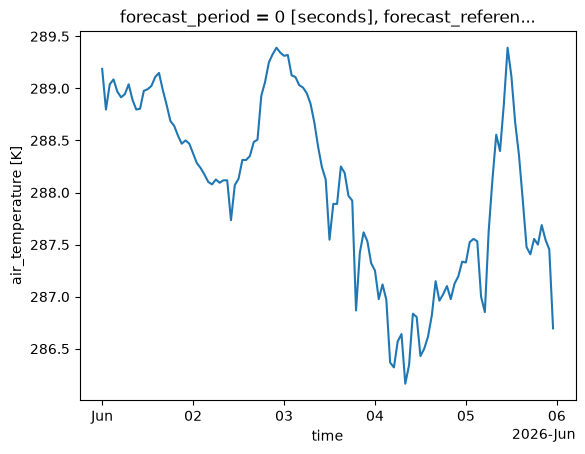

In [8]:
ds["air_temperature"].isel(projection_x_coordinate=100, projection_y_coordinate=100).plot()

## Legacy format versus Icechunk query comparisons

With the virtual array written to Icechunk we can compare a few common query patterns against the legacy workflow. For the legacy path we re-run a STAC search for the same `PT0000H00M` UK near-surface records, but now the temporal constraint is pushed down into the STAC query so the legacy path only opens the raw NetCDF assets needed for each comparison.

The examples below time four representative access patterns for `air_temperature`: a time slice, a single point, a spatial slice, and a full-array load. To keep the comparison aligned across both approaches, each query uses `sel` with actual timestamp values rather than `isel` along the time dimension where appropriate.

In [11]:
import logging
import time
from contextlib import contextmanager
from dataclasses import dataclass

import pandas as pd
from obspec_utils.readers import EagerStoreReader


logger = logging.getLogger("met_office_benchmark")
if not logger.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(message)s"))
    logger.addHandler(handler)
logger.setLevel(logging.INFO)
logger.propagate = False


@dataclass
class Timing:
    label: str
    seconds: float | None = None


LEGACY_ASSET_KEY = "temperature_at_screen_level"
DATA_VARIABLE = "air_temperature"
LEGACY_CHUNKS = {
    "time": 1,
    "projection_y_coordinate": 256,
    "projection_x_coordinate": 256,
}

time_slice_start = pd.Timestamp(ds.time.isel(time=24).values)
time_slice_end = pd.Timestamp(ds.time.isel(time=47).values)
single_time = pd.Timestamp(ds.time.isel(time=36).values)
full_time_start = pd.Timestamp(ds.time.min().values)
full_time_end = pd.Timestamp(ds.time.max().values)


@contextmanager
def timer(label="Task"):
    """Time a block and expose the elapsed seconds after it exits."""
    timing = Timing(label=label)
    t0 = time.perf_counter()
    logger.info("Starting %s", label)
    try:
        yield timing
    finally:
        timing.seconds = time.perf_counter() - t0
        logger.info("%s took %.2f seconds", label, timing.seconds)


def to_stac_datetime(value):
    """Convert a timestamp-like value to an RFC3339 UTC string for STAC."""
    return pd.Timestamp(value).tz_localize("UTC").isoformat().replace("+00:00", "Z")


@contextmanager
def open_icechunk():
    """Open the local Icechunk repository as an xarray dataset."""
    with timer("icechunk: Repository.open"):
        repo = ic.Repository.open(storage, config, credentials)
    with timer("icechunk: readonly_session"):
        session = repo.readonly_session("main")
    with timer("icechunk: xr.open_zarr"):
        dataset = xr.open_zarr(session.store, zarr_format=3, consolidated=False)
    logger.info("icechunk dataset dims: %s", dict(dataset.sizes))
    try:
        yield dataset
    finally:
        dataset.close()
        if hasattr(session, "close"):
            session.close()


@contextmanager
def open_legacy(datetime_query):
    """Open the legacy NetCDF assets matched by a targeted STAC query."""
    with timer(f"legacy: STAC search ({datetime_query})"):
        legacy_search = catalog.search(
            collections="met-office-uk-deterministic-near-surface",
            datetime=datetime_query,
            filter_lang="cql2-json",
            filter={
                "op": "=",
                "args": [
                    {"property": "forecast:horizon"},
                    "PT0000H00M",
                ],
            },
            sortby="datetime",
            limit=100,
        )

        legacy_items = legacy_search.item_collection()
        
    with timer("legacy: collect asset paths"):
        asset_paths = [
            urlparse(item.assets[LEGACY_ASSET_KEY].href).path.lstrip("/")
            for item in legacy_items
            if LEGACY_ASSET_KEY in item.assets
        ]
        
    logger.info("legacy matched %s items and %s assets", len(legacy_items), len(asset_paths))

    with timer("legacy: xr.open_mfdataset"):
        dataset = xr.open_mfdataset(
            [EagerStoreReader(base_store, path) for path in asset_paths],
            engine="h5netcdf",
            chunks=LEGACY_CHUNKS,
            decode_times=True,
            decode_timedelta=True,
            concat_dim="time",
            combine="nested",
            parallel=True,
            coords="minimal",
            compat="override",
        )
    logger.info("legacy dataset dims: %s", dict(dataset.sizes))
    try:
        yield dataset
    finally:
        dataset.close()


In [12]:
results = []

with timer("icechunk time slice") as t:
    with open_icechunk() as icechunk_ds:
        icechunk_ds[DATA_VARIABLE].sel(time=slice(time_slice_start, time_slice_end)).load()
results.append({"query": "time slice", "backend": "icechunk", "seconds": t.seconds})

with timer("legacy time slice") as t:
    with open_legacy(f"{to_stac_datetime(time_slice_start)}/{to_stac_datetime(time_slice_end)}") as legacy_ds:
        legacy_ds[DATA_VARIABLE].sel(time=slice(time_slice_start, time_slice_end)).load()
results.append({"query": "time slice", "backend": "legacy-stac-plus-netcdf", "seconds": t.seconds})

with timer("icechunk random point") as t:
    with open_icechunk() as icechunk_ds:
        icechunk_ds[DATA_VARIABLE].sel(time=single_time).isel(
            projection_y_coordinate=187,
            projection_x_coordinate=241,
        ).load()
results.append({"query": "random point", "backend": "icechunk", "seconds": t.seconds})

with timer("legacy random point") as t:
    with open_legacy(to_stac_datetime(single_time)) as legacy_ds:
        legacy_ds[DATA_VARIABLE].sel(time=single_time).isel(
            projection_y_coordinate=187,
            projection_x_coordinate=241,
        ).load()
results.append({"query": "random point", "backend": "legacy-stac-plus-netcdf", "seconds": t.seconds})

with timer("icechunk spatial slice") as t:
    with open_icechunk() as icechunk_ds:
        icechunk_ds[DATA_VARIABLE].sel(time=single_time).isel(
            projection_y_coordinate=slice(150, 406),
            projection_x_coordinate=slice(200, 456),
        ).load()
results.append({"query": "spatial slice", "backend": "icechunk", "seconds": t.seconds})

with timer("legacy spatial slice") as t:
    with open_legacy(to_stac_datetime(single_time)) as legacy_ds:
        legacy_ds[DATA_VARIABLE].sel(time=single_time).isel(
            projection_y_coordinate=slice(150, 406),
            projection_x_coordinate=slice(200, 456),
        ).load()
results.append({"query": "spatial slice", "backend": "legacy-stac-plus-netcdf", "seconds": t.seconds})

with timer("icechunk full array") as t:
    with open_icechunk() as icechunk_ds:
        icechunk_ds[DATA_VARIABLE].load()
results.append({"query": "full array", "backend": "icechunk", "seconds": t.seconds})

with timer("legacy full array") as t:
    with open_legacy(f"{to_stac_datetime(full_time_start)}/{to_stac_datetime(full_time_end)}") as legacy_ds:
        legacy_ds[DATA_VARIABLE].load()
results.append({"query": "full array", "backend": "legacy-stac-plus-netcdf", "seconds": t.seconds})

comparison_df = (
    pd.DataFrame(results)
    .pivot(index="query", columns="backend", values="seconds")
    .rename(
        columns={
            "icechunk": "icechunk_seconds",
            "legacy-stac-plus-netcdf": "legacy_seconds",
        }
    )
    [["legacy_seconds", "icechunk_seconds"]]
    .round(2)
)

comparison_df


Starting icechunk time slice
Starting icechunk: Repository.open
icechunk: Repository.open took 0.00 seconds
Starting icechunk: readonly_session
icechunk: readonly_session took 0.00 seconds
Starting icechunk: xr.open_zarr
icechunk: xr.open_zarr took 1.83 seconds
icechunk dataset dims: {'time': 120, 'projection_y_coordinate': 970, 'projection_x_coordinate': 1042, 'bnds': 2}
icechunk time slice took 20.94 seconds
Starting legacy time slice
Starting legacy: STAC search (2026-06-02T00:00:00Z/2026-06-02T23:00:00Z)
legacy: STAC search (2026-06-02T00:00:00Z/2026-06-02T23:00:00Z) took 0.00 seconds
Starting legacy: item_collection
legacy: item_collection took 0.80 seconds
Starting legacy: collect asset paths
legacy: collect asset paths took 0.00 seconds
legacy matched 24 items and 24 assets
Starting legacy: xr.open_mfdataset
legacy: xr.open_mfdataset took 10.61 seconds
legacy dataset dims: {'time': 24, 'projection_y_coordinate': 970, 'projection_x_coordinate': 1042, 'bnds': 2}
legacy time slice 

backend,legacy_seconds,icechunk_seconds
query,,
full array,78.31,88.89
random point,0.67,2.11
spatial slice,0.73,2.18
time slice,12.53,20.94


If you want a cleaner comparison you can rerun the benchmark cell a few times and ignore the first pass, since both approaches may benefit from local caching and warmed network connections.

In [1]:
! rm -r /tmp/metoffice-deterministic-uk-local/